## Synapse summaries

### Goal: count how many synapses are between the cells in the OB network

Notes:
- All GCs are sources and all MCs and TCs are dest's
- The json defines all the connections so if "is_reciprocal": true, it means there is a recirocal connection
- Gap junctions are created in olfactorybulb > model.py but the .json synapses file only includes the MC/GC and TC/GC synapses

In [1]:
import json
import yaml
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [8]:
def get_synapses(file_name, slices_dir, slice_name):
    """
    args: 
    file_name: str (e.g. 'GCs__MCs')
    slices_dir: location of the synapses .json files
    slice_name: str (e.g. 'DorsalColumnSlice')
    """

    source_cells = []
    inh_cell_sections = []   
    source_cell_ids = []
    dest_cells = []    # i.e. TC4[2]
    exc_cell_sections = []     # i.e. "TC4[2].dend[7]"
    dest_cell_ids = []     # i.e. 2


    # import file into a dictionary
    with open(f'{slices_dir}/{slice_name}/{file_name}.json','r') as f:
        cells = json.load(f)

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        # get the source and destination cell types (first three characters, i.e. MC5, MC4, ...) 
        source_cell = entry['source_section'].split('.')[0]
        inh_cell_section = entry['source_section']
        source_cells.append(source_cell)
        inh_cell_sections.append(inh_cell_section)
        exc_cell_section = entry['dest_section']
        dest_cell = entry['dest_section'].split('.')[0]
        dest_cells.append(dest_cell)
        exc_cell_sections.append(exc_cell_section)

        # to get the cell number that's inside the brackets
        source_cell_id = int(source_cell[3:][1:-1])
        source_cell_ids.append(source_cell_id)
        dest_cell_id = int(dest_cell[3:][1:-1])
        dest_cell_ids.append(dest_cell_id)

        # check that all synapses are reciprocal
        assert entry['is_reciprocal'] == True 

        # check that all weights are 1
        assert entry['weight'] == 1.0
        
    # ordering the GCs and MC/TCs in order of cell type number using only unique cell id's
    inh_cells = sorted(set(source_cells))
    #print("inh cells:", inh_cells)
    print("inh cells:", inh_cells)
    exc_cells = sorted(set(dest_cells))
    print("exc cells:", exc_cells)

    # initialize DataFrame
    syn_df = pd.DataFrame(0, columns = inh_cells, index = exc_cells)

    # iterate over connections (entries) in file
    for entry in cells['entries']:
        source_cell = entry['source_section'].split('.')[0]
        dest_cell = entry['dest_section'].split('.')[0]
        # increment synapse counts - all GCs are sources and all MCs and TCs are dest's
        syn_df.loc[dest_cell][source_cell] = syn_df.loc[dest_cell][source_cell] + 1

    syn_df.loc[:,'Row_Total'] = syn_df.sum(axis=1)
    syn_df.loc['Column_Total']= syn_df.sum(axis=0)

    # write DataFrame to pickle (for reimporting as a DataFrame) and yaml (for viewing) files
    #syn_df.to_pickle(f'{slices_dir}/{file_name}_synapse_counts.pkl', protocol=3)
    #with open(f'{slices_dir}/{file_name}_synapse_counts.yaml', 'w') as outfile:
    #    yaml.dump(syn_df.to_dict(),outfile)

    return syn_df, inh_cell_sections, exc_cell_sections, exc_cells, inh_cells


In [14]:
def get_cropped_df(df):
    # to get rid of the sum row and column 
    df.drop(df.tail(1).index,inplace=True)
    df.drop(columns=['Row_Total'], inplace=True)
    df = df
    return df

In [15]:
def get_syn_maxmin_df(df):
    
    df.loc[:, 'Row_Max'] = df.max(axis=1)

    maxValueIndex = df.idxmax(axis=1)     # find the column name of max values in every row
    df['Max_idx'] = np.array(maxValueIndex)
    df.loc['Column_Max'] = df.max(axis=0)

    df.loc[:, 'Row_Min'] = df.min(axis=1)
    df.loc['Column_Min'] = df.min(axis=0)
    return df

In [16]:
def plot_synapse_heatmap(df):
    ##syn_df.sort_index(level=0, ascending=True, inplace=True)
    get_cropped_df(df)
    fig, ax = plt.subplots(figsize=(15, 5))
    
    sns.heatmap(df, cmap="Blues")

In [17]:
def get_cell_info(file_name, slices_dir, slice_name):
    
    radii = []      # the (x,y,z) coordinates of each cell soma
    children = []   # 
    names = []

    # import file into a dictionary
    with open(f'{slices_dir}/{slice_name}/{file_name}.json','r') as f:
        cells = json.load(f)

    for root in cells['roots']:
        radii_cell = root['radii']
        radii.append(radii_cell)
        children_cell = root['children']
        children.append(children_cell)
        name = root['name'].split('.')[0]
        names.append(name)
    
    return radii, children, names

### Define location of slice files  

In [18]:
# define directory where slice .json files are located and slice name
slices_dir = os.path.join('/home/ellismith/OlfactoryBulb/olfactorybulb/slices')
slice_name = 'DorsalColumnSlice'

### MC-GC synapses

In [19]:
# gc_sect_to_mc is a list of which GC sections form synapses with MCs
# gcs_conn_to_mcs is a list of which GCs form synapses with MCs
mc_syn_df, gc_sect_to_mc, mc_sect_to_gc, mcs_conn_to_gcs, gcs_conn_to_mcs = get_synapses('GCs__MCs', slices_dir, slice_name)
mc_syn_df1 =mc_syn_df.iloc[:,-11:]   # to show just a portion of the dataframe
mc_syn_df1

inh cells: ['GC1[16]', 'GC1[18]', 'GC1[24]', 'GC1[28]', 'GC1[2]', 'GC1[32]', 'GC1[36]', 'GC1[54]', 'GC1[56]', 'GC1[58]', 'GC1[60]', 'GC1[62]', 'GC1[64]', 'GC1[68]', 'GC1[72]', 'GC1[74]', 'GC1[86]', 'GC1[8]', 'GC1[92]', 'GC1[94]', 'GC1[96]', 'GC1[98]', 'GC2[10]', 'GC2[2]', 'GC2[4]', 'GC3[0]', 'GC3[104]', 'GC3[106]', 'GC3[108]', 'GC3[112]', 'GC3[114]', 'GC3[116]', 'GC3[118]', 'GC3[136]', 'GC3[140]', 'GC3[142]', 'GC3[156]', 'GC3[160]', 'GC3[162]', 'GC3[168]', 'GC3[174]', 'GC3[176]', 'GC3[18]', 'GC3[196]', 'GC3[200]', 'GC3[206]', 'GC3[208]', 'GC3[20]', 'GC3[210]', 'GC3[220]', 'GC3[222]', 'GC3[224]', 'GC3[226]', 'GC3[22]', 'GC3[234]', 'GC3[236]', 'GC3[238]', 'GC3[24]', 'GC3[254]', 'GC3[260]', 'GC3[266]', 'GC3[276]', 'GC3[286]', 'GC3[28]', 'GC3[296]', 'GC3[300]', 'GC3[302]', 'GC3[306]', 'GC3[308]', 'GC3[310]', 'GC3[314]', 'GC3[36]', 'GC3[40]', 'GC3[4]', 'GC3[50]', 'GC3[54]', 'GC3[60]', 'GC3[64]', 'GC3[66]', 'GC3[68]', 'GC3[6]', 'GC3[74]', 'GC3[76]', 'GC3[80]', 'GC3[82]', 'GC3[86]', 'GC3[90]'

,GC5[38],GC5[42],GC5[46],GC5[48],GC5[50],GC5[54],GC5[58],GC5[64],GC5[68],GC5[70],Row_Total
MC4[0],0,4,2,0,2,3,0,0,0,4,134
MC5[0],0,0,0,0,0,0,0,0,0,0,131
MC5[2],0,0,0,0,0,0,0,0,0,0,57
MC5[4],3,0,0,0,0,0,0,0,0,0,140
MC5[6],0,0,0,4,2,2,1,1,4,0,116
Column_Total,3,4,2,4,4,5,1,1,4,4,578


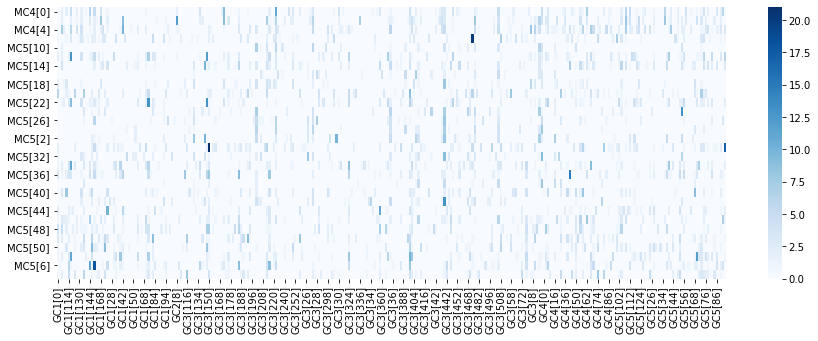

In [28]:
plot_synapse_heatmap(mc_syn_df)

In [20]:
mc_syn_df_ = get_syn_maxmin_df(mc_syn_df)
mc_syn_df_

,GC1[16],GC1[18],GC1[24],GC1[28],GC1[2],GC1[32],GC1[36],GC1[54],GC1[56],GC1[58],...,GC5[50],GC5[54],GC5[58],GC5[64],GC5[68],GC5[70],Row_Total,Row_Max,Max_idx,Row_Min
MC4[0],1,3,0,2,0,0,0,6,3,0,...,2,3,0,0,0,4,134,134,Row_Total,0
MC5[0],0,0,0,0,0,2,4,0,0,0,...,0,0,0,0,0,0,131,131,Row_Total,0
MC5[2],0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,57,57,Row_Total,0
MC5[4],4,2,0,0,2,7,1,0,0,2,...,0,0,0,0,0,0,140,140,Row_Total,0
MC5[6],0,5,0,2,7,0,0,0,0,0,...,2,2,1,1,4,0,116,116,Row_Total,0
Column_Total,5,10,1,4,9,9,5,6,3,2,...,4,5,1,1,4,4,578,578,Row_Total,1
Column_Max,5,10,1,4,9,9,5,6,3,2,...,4,5,1,1,4,4,578,578,Row_Total,1
Column_Min,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,57,57,Row_Total,0


### TC-GC synapses

In [21]:
tc_syn_df, gc_sect_to_tc, tc_sect_to_gc, tcs_conn_to_gcs, gcs_conn_to_tcs = get_synapses('GCs__TCs', slices_dir, slice_name)
pd.set_option('display.max_rows', None)
tc_syn_df1 =tc_syn_df.iloc[:,-11:] # show subset of GCs
tc_syn_df1

inh cells: ['GC1[16]', 'GC1[18]', 'GC1[28]', 'GC1[2]', 'GC1[54]', 'GC1[56]', 'GC1[58]', 'GC1[64]', 'GC1[72]', 'GC1[74]', 'GC1[82]', 'GC1[8]', 'GC1[92]', 'GC1[94]', 'GC1[98]', 'GC3[0]', 'GC3[102]', 'GC3[108]', 'GC3[142]', 'GC3[162]', 'GC3[208]', 'GC3[20]', 'GC3[220]', 'GC3[224]', 'GC3[226]', 'GC3[266]', 'GC3[36]', 'GC3[50]', 'GC3[72]', 'GC3[80]', 'GC3[90]', 'GC4[0]', 'GC4[12]', 'GC4[14]', 'GC4[16]', 'GC4[22]', 'GC4[30]', 'GC4[32]', 'GC4[34]', 'GC4[44]', 'GC5[20]', 'GC5[24]', 'GC5[56]', 'GC5[60]', 'GC5[64]']
exc cells: ['TC3[0]', 'TC3[2]', 'TC4[0]', 'TC4[2]', 'TC4[4]', 'TC4[6]', 'TC5[0]', 'TC5[10]', 'TC5[2]', 'TC5[4]', 'TC5[6]', 'TC5[8]']


,GC4[22],GC4[30],GC4[32],GC4[34],GC4[44],GC5[20],GC5[24],GC5[56],GC5[60],GC5[64],Row_Total
TC3[0],0,0,0,0,0,0,0,0,0,0,7
TC3[2],0,0,0,0,0,0,0,0,0,0,11
TC4[0],0,0,0,0,0,0,0,0,0,0,62
TC4[2],0,0,0,0,12,0,8,10,0,0,139
TC4[4],0,0,0,0,2,0,0,0,0,0,5
TC4[6],0,0,0,8,6,0,3,0,0,2,59
TC5[0],0,0,0,0,0,0,2,0,0,0,35
TC5[10],1,0,0,0,0,0,0,0,0,0,7
TC5[2],0,0,3,0,0,0,0,0,0,0,14
TC5[4],0,0,0,0,0,0,6,0,0,11,51


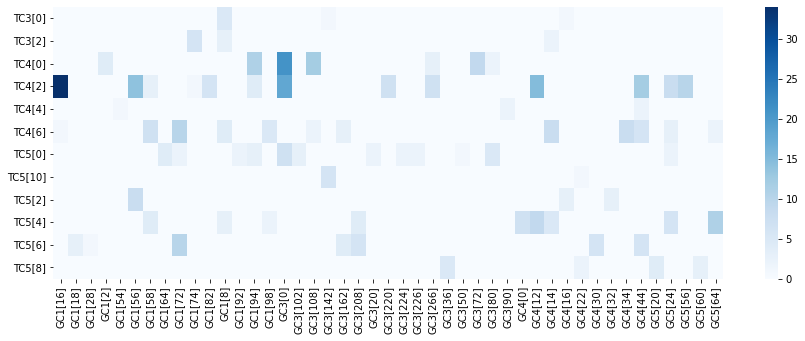

In [22]:
plot_synapse_heatmap(tc_syn_df)

In [23]:
tc_syn_df_ = get_syn_maxmin_df(tc_syn_df)
tc_syn_df_

,GC1[16],GC1[18],GC1[28],GC1[2],GC1[54],GC1[56],GC1[58],GC1[64],GC1[72],GC1[74],...,GC4[34],GC4[44],GC5[20],GC5[24],GC5[56],GC5[60],GC5[64],Row_Max,Max_idx,Row_Min
TC3[0],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5,GC1[8],0
TC3[2],0,0,0,0,0,0,0,0,0,6,...,0,0,0,0,0,0,0,6,GC1[74],0
TC4[0],0,0,0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,21,GC3[0],0
TC4[2],34,0,0,0,0,14,3,0,0,1,...,0,12,0,8,10,0,0,34,GC1[16],0
TC4[4],0,0,0,0,1,0,0,0,0,0,...,0,2,0,0,0,0,0,2,GC3[90],0
TC4[6],1,0,0,0,0,0,7,0,10,0,...,8,6,0,3,0,0,2,10,GC1[72],0
TC5[0],0,0,0,0,0,0,0,4,2,0,...,0,0,0,2,0,0,0,7,GC3[0],0
TC5[10],0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,6,GC3[142],0
TC5[2],0,0,0,0,0,8,0,0,0,0,...,0,0,0,0,0,0,0,8,GC1[56],0
TC5[4],0,0,0,0,0,0,4,0,0,0,...,0,0,0,6,0,0,11,11,GC5[64],0


In [24]:
gcs_to_mcs = set(gcs_conn_to_mcs)
gcs_to_tcs = set(gcs_conn_to_tcs)
gcs_total = gcs_to_mcs.union(gcs_to_tcs)
len(gcs_total)


121

In [25]:
cell_types = ['MCs', 'TCs', 'GCs']

mc_radii, mc_children, mc_names = get_cell_info('MCs', slices_dir, slice_name)
tc_radii, tc_children, tc_names = get_cell_info('TCs', slices_dir, slice_name)
gc_radii, gc_children, gc_names = get_cell_info('GCs', slices_dir, slice_name)

# initialize cell info DataFrame
cols = 'num_cells', 'cells_syn_w_MCs', 'cells_syn_w_TCs', 'cells_syn_w_GCs', 'total_syn_w_MCs', 'total_syn_w_TCs', 'total_syn_w_GCs'
cell_df = pd.DataFrame(0, columns = cols, index = cell_types)

In [18]:
cell_df.loc['MCs']['num_cells'] = len(mc_radii)
cell_df.loc['TCs']['num_cells'] = len(tc_radii)
cell_df.loc['GCs']['num_cells'] = len(gc_radii)
#assert(len(gc_radii)==len(gcs_total))  # check that the gcs that form synapses are the same gcs from GCs.json

cell_df.loc['MCs']['cells_syn_w_GCs'] = len(mcs_conn_to_gcs)
cell_df.loc['GCs']['cells_syn_w_MCs'] = len(gcs_conn_to_mcs)
cell_df.loc['TCs']['cells_syn_w_GCs'] = len(tcs_conn_to_gcs)
cell_df.loc['GCs']['cells_syn_w_TCs'] = len(gcs_conn_to_tcs)

cell_df.loc['MCs']['total_syn_w_GCs'] = len(mc_sect_to_gc)
cell_df.loc['GCs']['total_syn_w_MCs'] = len(gc_sect_to_mc)
cell_df.loc['TCs']['total_syn_w_GCs'] = len(tc_sect_to_gc)
cell_df.loc['GCs']['total_syn_w_TCs'] = len(gc_sect_to_tc)

cell_df

,num_cells,cells_syn_w_MCs,cells_syn_w_TCs,cells_syn_w_GCs,total_syn_w_MCs,total_syn_w_TCs,total_syn_w_GCs
MCs,30,0,0,30,0,0,4860
TCs,71,0,0,71,0,0,5777
GCs,311,310,122,0,4860,5777,0
